In [14]:
# =============================================================================
# Quina taula de multiplicar es mes dificil? (A998, Espanya, curs 2025-26)
# =============================================================================
# Pregunta del Learning Team: quina taula costa mes -- desglossat en error rate
# i response time -- i com varia amb l'edat. Enfocament inicial: taules 6/7/8/9.
#
# "Taula del X" es ambigua (8x7 es taula del 8 o del 7?), aixi que aquest
# notebook calcula TRES definicions en paral·lel des d'una unica query
# agregada (a998_table_difficulty_by_age.sql):
#   'either'  -- X es qualsevol dels dos factors (8x7 i 7x8 compten per taula 8)
#   'first'   -- X es estrictament el primer factor  (8x7 si, 7x8 no)
#   'second'  -- X es estrictament el segon factor    (7x8 si, 8x7 no)
# L'asimetria commutativa en si (8x7 vs 7x8 es responen diferent?) queda per
# mes endavant -- aqui nomes es defineix "taula", no es mesura l'asimetria.
#
# Decisions heretades de Learning_Team_Plots/Decisions.txt:
#   #1 A998 nomes  ·  #2 edats 8-15 (classroom_course_age)  ·  #5 nomes
#   multiplicacions per classificar taula  ·  #7 es descarta el primer
#   statement de cada pack-sitting (biaix de compte enrere / orientacio)
#
# Error rate = (Incorrect + Help) / n intents.
# Response time = mitjana nomes sobre respostes CORRECTES (convencio de
# rt_A998_answers.sql: una resposta incorrecta rapida no es evidencia de
# fluidesa).
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


HERE = Path.cwd()          # descriptive/ or mechanistic/ (run the notebook from its own folder)
ROOT = HERE
while not (ROOT / "databricks_connector.py").exists():
    if ROOT == ROOT.parent:
        raise FileNotFoundError("databricks_connector.py not found in any parent directory")
    ROOT = ROOT.parent      # repo root -- holds databricks_connector.py and cached_query.py
sys.path.insert(0, str(ROOT))
from cached_query import cached_query
(HERE / "cache").mkdir(exist_ok=True)
(HERE / "plots").mkdir(exist_ok=True)

SQL_PATH = HERE / "queries" / "a998_table_difficulty_by_age.sql"
CACHE_DIR = HERE / "cache"

agg_all = cached_query(SQL_PATH, CACHE_DIR)

DEFINITIONS = {
    "either": "Taula del X = X es qualsevol dels dos factors (8x7 i 7x8 compten per taula del 8)",
    "first":  "Taula del X = X es estrictament el primer factor (8x7 si, 7x8 no)",
    "second": "Taula del X = X es estrictament el segon factor (7x8 si, 8x7 no)",
}

print("A998 | bi_gold_prod.dm_research.fluency_test_statements x fluency_test_metrics")
print("Scope: ES_2025, multiplicacions nomes, edats 8-15, statement_idx>=1 (Decisions #1,#2,#5,#7)")
print("Error rate = (Incorrect + Help) / n | mean_rt = segons en respostes CORRECTES nomes")
print(f"Files agregades: {len(agg_all):,} (definicio x taula x edat) | cache -> {CACHE_DIR.relative_to(ROOT)}/")
for mode, desc in DEFINITIONS.items():
    print(f"  [{mode}] {desc}")

A998 | bi_gold_prod.dm_research.fluency_test_statements x fluency_test_metrics
Scope: ES_2025, multiplicacions nomes, edats 8-15, statement_idx>=1 (Decisions #1,#2,#5,#7)
Error rate = (Incorrect + Help) / n | mean_rt = segons en respostes CORRECTES nomes
Files agregades: 240 (definicio x taula x edat) | cache -> descriptive\cache/
  [either] Taula del X = X es qualsevol dels dos factors (8x7 i 7x8 compten per taula del 8)
  [first] Taula del X = X es estrictament el primer factor (8x7 si, 7x8 no)
  [second] Taula del X = X es estrictament el segon factor (7x8 si, 8x7 no)


In [15]:
# --- cobertura: quants intents hi ha per taula x edat? -----------------------
# Decisio #4: els packs canvien per edat x trimestre, aixi que no totes les
# taules es practiquen a totes les edats (p.ex. edat 8 T1 nomes veu taules 2 i
# 5). Una linia fluixa o absent en una edat jove es curriculum, no un forat de
# dades -- per aixo es mira `n` abans de confiar en cap punt.
MIN_N = 200

cov = (agg_all[agg_all["definition"] == "first"]
       .pivot(index="classroom_course_age", columns="mult_table", values="n")
       .fillna(0).astype(int))
print("Intents per taula x edat (definicio 'first', per veure forats de curriculum):")
print(cov)

sparse = agg_all[agg_all["n"] < MIN_N]
print(f"\n{len(sparse)} / {len(agg_all)} caselles (definicio x taula x edat) tenen n < {MIN_N} -- s'exclouen dels grafics.")

Intents per taula x edat (definicio 'first', per veure forats de curriculum):
mult_table                0       1       2       3       4       5       6  \
classroom_course_age                                                          
8                        29  143685  141845  140889  139741  141106  139124   
9                     21919  131782  130217  129097  128303  129923  127775   
10                    80254   83538   82965   82390   81411   82287   81143   
11                    86554   89551   88726   87828   87337   88086   87428   
12                    38841   38933   38840   38539   38108   38571   38008   
13                    39108   38852   39132   38617   38485   38557   38534   
14                    20031   19906   19921   19761   19462   19667   19594   
15                     5691    5728    5649    5614    5585    5716    5542   

mult_table                 7       8       9  
classroom_course_age                          
8                     138825  138803 

In [16]:
# --- funcio de plot compartida per les 3 definicions -------------------------
# Cada taula (0-9) te un color propi i fix (paleta tab10, 10 colors -> 1 color
# per taula, sempre el mateix als 3 grafics) i apareix a la llegenda, aixi que
# es pot identificar qualsevol corba. Les taules 6/7/8/9 (l'interes original
# del Learning Team) es dibuixen mes gruixudes per seguir-les d'un cop d'ull,
# pero ja no calen colors especials per distingir-les de la resta.
#
# Corbes suavitzades amb interpolacio PCHIP (mateixa tecnica que
# corrected_operations_boxplot.ipynb): monotona i sense overshoot entre punts
# -- suavitza la linia sense inventar-se tendencies que les dades no tenen.
# Nomes es dibuixa entre el primer i l'ultim punt real; no s'extrapola.
#
# Mida dels punts = quantitat de dades promitjades en aquell punt: al panell
# d'error rate, `n` (intents); al panell de RT, `n_correct` (nomes les
# respostes correctes hi entren a la mitjana). Escala per area (sqrt(n)) i
# normalitzada per PANELL, no per taula/mode, aixi la mida es comparable entre
# corbes dins del mateix grafic.
from scipy.interpolate import PchipInterpolator

TABLE_COLORS = {t: plt.cm.tab10(t / 9) for t in range(10)}
HIGHLIGHT = {6, 7, 8, 9}
AGES = list(range(8, 16))
SIZE_RANGE = (12, 220)   # points^2, min/max marker area

def sizes_from_n(n_values, all_n):
    r = np.sqrt(n_values.astype(float))
    rmin, rmax = np.sqrt(all_n.min()), np.sqrt(all_n.max())
    lo, hi = SIZE_RANGE
    if rmax == rmin:
        return np.full_like(r, (lo + hi) / 2)
    return lo + (hi - lo) * (r - rmin) / (rmax - rmin)

def add_size_legend(ax, all_n, size_title, bbox_to_anchor):
    """Llegenda de mides: 3 punts de referencia (n minim, geometric mig, n maxim
    del panell) amb la mida real que tindrien al grafic, per poder llegir `n`
    directament d'una corba. Ancorada per bbox_to_anchor perque quedi al costat
    (a l'esquerra) de la llegenda de colors, no a sota."""
    lo_n, hi_n = all_n.min(), all_n.max()
    if hi_n == lo_n:
        n_ref = np.array([lo_n])
    else:
        n_ref = np.unique(np.round(np.geomspace(lo_n, hi_n, 3), -2).astype(int))
    sizes_ref = sizes_from_n(n_ref.astype(float), all_n)
    handles = [ax.scatter([], [], s=s, color="0.45", edgecolors="white", linewidths=0.4)
               for s in sizes_ref]
    labels = [f"n = {n:,}" for n in n_ref]
    leg = ax.legend(handles, labels, title=size_title, loc="upper right",
                     bbox_to_anchor=bbox_to_anchor, fontsize=7,
                     title_fontsize=7, labelspacing=1.4, borderpad=1.1, handletextpad=1.6)
    ax.add_artist(leg)

def plot_mode(mode):
    d = agg_all[(agg_all["definition"] == mode) & (agg_all["n"] >= MIN_N)]
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    all_n_err = d["n"].to_numpy()
    all_n_rt = d["n_correct"].to_numpy()

    for table in sorted(d["mult_table"].unique()):
        sub = d[d["mult_table"] == table].sort_values("classroom_course_age")
        if len(sub) < 2:
            continue
        color = TABLE_COLORS[table]
        lw = 2.6 if table in HIGHLIGHT else 1.3
        z = 3 if table in HIGHLIGHT else 2
        label = f"taula {table}"

        x = sub["classroom_course_age"].to_numpy()
        x_smooth = np.linspace(x.min(), x.max(), 200)

        y_err = PchipInterpolator(x, sub["error_rate"].to_numpy())(x_smooth)
        axes[0].plot(x_smooth, y_err, color=color, lw=lw, zorder=z, label=label)
        s_err = sizes_from_n(sub["n"].to_numpy(), all_n_err)
        axes[0].scatter(x, sub["error_rate"], s=s_err, color=color, zorder=z, edgecolors="white", linewidths=0.4)

        y_rt = PchipInterpolator(x, sub["mean_rt"].to_numpy())(x_smooth)
        axes[1].plot(x_smooth, y_rt, color=color, lw=lw, zorder=z, label=label)
        s_rt = sizes_from_n(sub["n_correct"].to_numpy(), all_n_rt)
        axes[1].scatter(x, sub["mean_rt"], s=s_rt, color=color, zorder=z, edgecolors="white", linewidths=0.4)

    axes[0].set_title("Error rate per taula (mida punt ~ n intents)")
    axes[0].set_xlabel("classroom_course_age")
    axes[0].set_ylabel("error rate (Incorrect + Help)")
    axes[1].set_title("Response time mitja per taula (mida punt ~ n correctes)")
    axes[1].set_xlabel("classroom_course_age")
    axes[1].set_ylabel("mean RT (s)")
    for ax in axes:
        ax.set_xticks(AGES)
        color_leg = ax.legend(fontsize=7.5, ncol=2, title="gruixut = 6/7/8/9",
                               title_fontsize=7.5, loc="upper right")
        ax.add_artist(color_leg)   # keep it alive once the size legend calls ax.legend() again
    add_size_legend(axes[0], all_n_err, "mida punt = n intents", bbox_to_anchor=(0.65, 1.0))
    add_size_legend(axes[1], all_n_rt, "mida punt = n correctes", bbox_to_anchor=(0.65, 1.0))
    fig.suptitle(f"A998 ES_2025 | definicio: {mode} | {DEFINITIONS[mode]}", fontsize=10)
    fig.tight_layout()
    out_path = HERE / "plots" / f"a998_table_difficulty_{mode}.png"
    fig.savefig(out_path, dpi=130)
    plt.show()
    print(f"Plot -> {out_path.relative_to(ROOT)}")

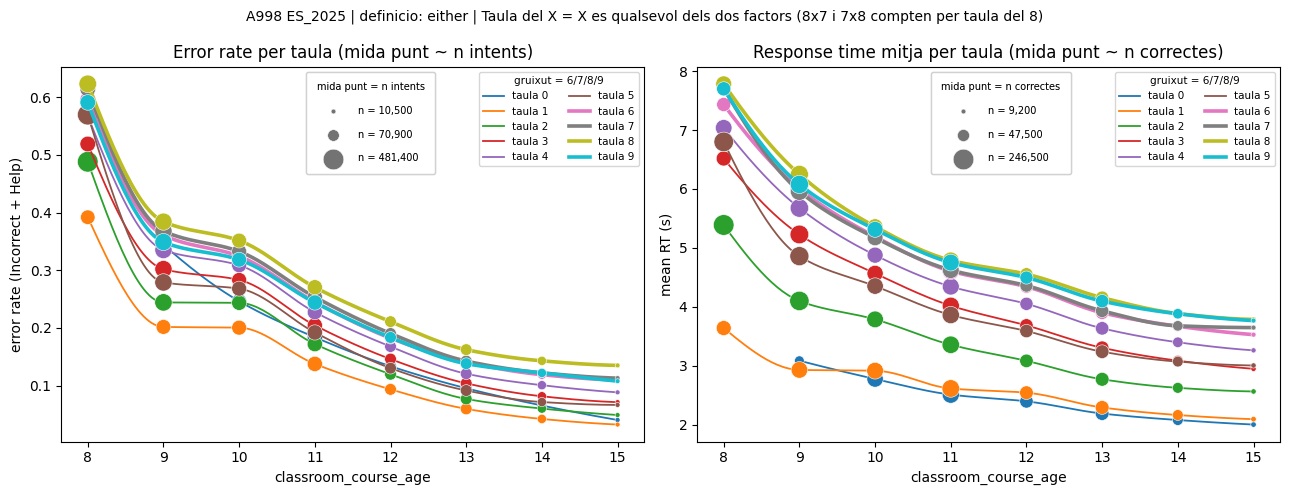

Plot -> descriptive\plots\a998_table_difficulty_either.png


In [17]:
# --- definicio A: 'either' (X es qualsevol dels dos factors) ----------------
plot_mode("either")

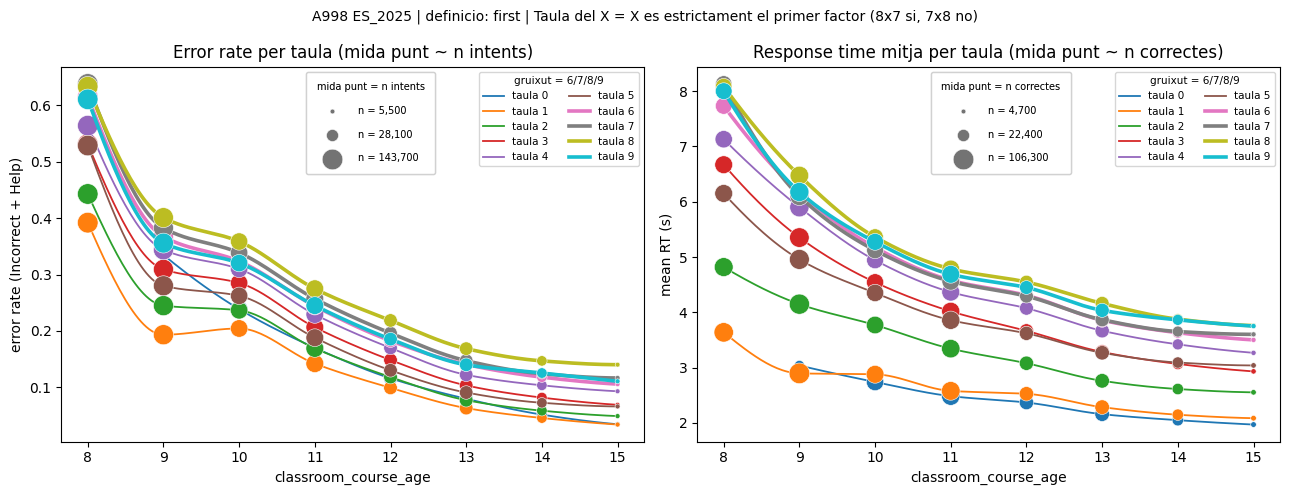

Plot -> descriptive\plots\a998_table_difficulty_first.png


In [18]:
# --- definicio B: 'first' (X es estrictament el primer factor) -------------
plot_mode("first")

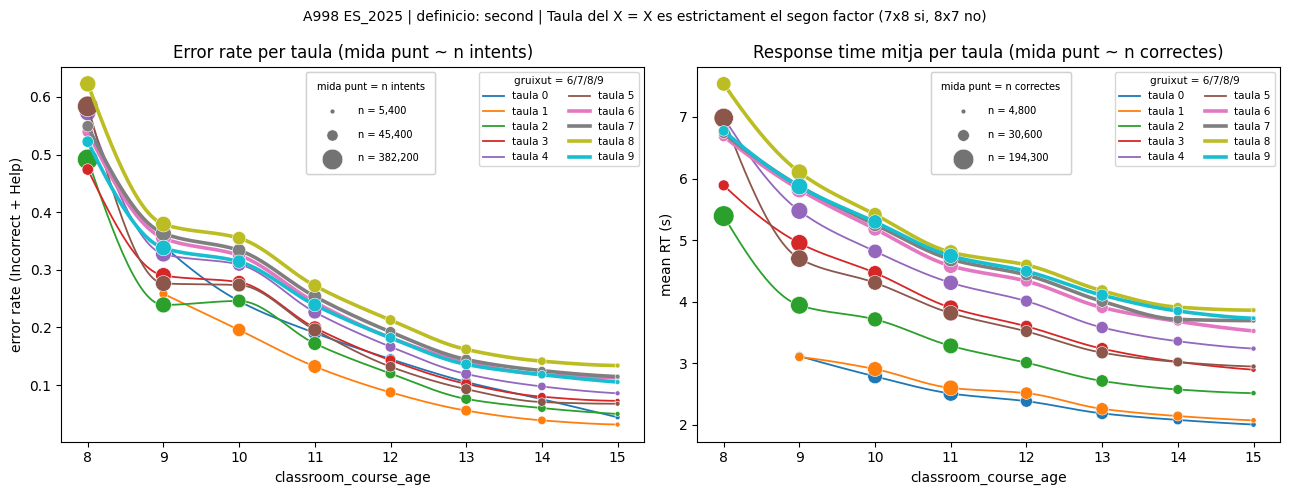

Plot -> descriptive\plots\a998_table_difficulty_second.png


In [19]:
# --- definicio C: 'second' (X es estrictament el segon factor) -------------
plot_mode("second")

In [20]:
# --- ranking: ordre descendent per error rate i per response time ----------
# Nomes una definicio ('first' i 'second' donarien basicament el mateix
# ordre per aquesta pregunta -- 'either' es l'unica que barreja els dos
# factors, aixi que la deixem fora d'aquest ranking puntual). Mitjana
# ponderada per n, totes les edats agrupades. Dues classificacions per
# separat (no es combinen en un sol score), per veure si "mes error" i "mes
# lent" son la mateixa taula o no.
MODE = "first"
d = agg_all[(agg_all["definition"] == MODE) & (agg_all["n"] >= MIN_N)]

summary = (d.groupby("mult_table")
             .apply(lambda g: pd.Series({
                 "n": g["n"].sum(),
                 "error_rate": np.average(g["error_rate"], weights=g["n"]),
                 "mean_rt": np.average(g["mean_rt"].fillna(0), weights=g["n_correct"].clip(lower=1)),
             }), include_groups=False))

print(f"[{MODE}] ordre descendent per ERROR RATE:")
print(summary.sort_values("error_rate", ascending=False)[["error_rate", "n"]].round(4))

print(f"\n[{MODE}] ordre descendent per RESPONSE TIME:")
print(summary.sort_values("mean_rt", ascending=False)[["mean_rt", "n"]].round(4))

[first] ordre descendent per ERROR RATE:
            error_rate         n
mult_table                      
8               0.3928  535186.0
7               0.3793  537261.0
6               0.3637  537148.0
9               0.3602  537773.0
4               0.3378  538432.0
3               0.3096  542735.0
5               0.2931  543913.0
2               0.2528  547295.0
1               0.2155  551975.0
0               0.1711  292398.0

[first] ordre descendent per RESPONSE TIME:
            mean_rt         n
mult_table                   
8            5.6471  535186.0
9            5.5226  537773.0
7            5.4006  537261.0
6            5.3863  537148.0
4            5.1374  538432.0
3            4.7257  542735.0
5            4.4773  543913.0
2            3.7707  547295.0
1            2.8624  551975.0
0            2.4716  292398.0


In [21]:
# =============================================================================
# Quin FET individual (a x b) es mes dificil? -- heatmaps per edat
# =============================================================================
# Grau mes fi que tot l'anterior: no per taula, sino per parella (factor_1,
# factor_2) exacta, tal com surt a `operation` (sense fusionar 8x7 amb 7x8 --
# per aixo la matriu no es simetrica; aixo deixa preparat, de franc, el terreny
# per la pregunta d'asimetria que vam ajornar).
#
# error_rate = mitjana de (Incorrect + Help), mateixa convencio que la resta
# del notebook.
# median_rt  = MEDIANA de statement_seconds_spent, nomes respostes CORRECTES
# (decisio presa amb Maria 2026-07-29: coherent amb rt_A998_answers.sql i amb
# el mean_rt de a998_table_difficulty_by_age.sql, pero mediana en lloc de
# mitjana perque aqui les caselles son mes petites i el RT te cua llarga).
SQL_PATH2 = HERE / "queries" / "a998_fact_heatmap_by_age.sql"

fact_df = cached_query(SQL_PATH2, CACHE_DIR)

print(f"Files: {len(fact_df):,} (factor_1 x factor_2 x edat) | cache -> {CACHE_DIR.relative_to(ROOT)}/")
print(fact_df["n"].describe().round(1))

Files: 798 (factor_1 x factor_2 x edat) | cache -> descriptive\cache/
count      798.0
mean      6471.4
std       7126.2
min          1.0
25%       2002.2
50%       3900.5
75%       8594.2
max      42808.0
Name: n, dtype: float64


In [22]:
# --- llindar de mostra per aquest grau mes fi ------------------------------
# A nivell de fet (no de taula) les caselles son ~10x mes petites. Hi ha un
# salt net a les dades: 26 caselles amb n <= 7 (totes a edat 8, forats de
# curriculum -- Decisio #4, packs que no cobreixen aquella parella concreta)
# i despres tot salta a n >= 491. FACT_MIN_N = 100 talla exactament aqui.
FACT_MIN_N = 100

sparse_facts = fact_df[fact_df["n"] < FACT_MIN_N]
print(f"{len(sparse_facts)} / {len(fact_df)} caselles (factor_1 x factor_2 x edat) tenen n < {FACT_MIN_N}.")
print("Totes concentrades a:")
print(sparse_facts["classroom_course_age"].value_counts().sort_index())

26 / 798 caselles (factor_1 x factor_2 x edat) tenen n < 100.
Totes concentrades a:
classroom_course_age
8    26
Name: count, dtype: int64


In [23]:
# --- funcio de heatmap compartida per totes les edats ----------------------
# Escala de color FIXA i compartida entre totes les edats (calculada un cop,
# sobre les caselles que superen FACT_MIN_N) perque les 8 edats es puguin
# comparar entre si amb el mateix criteri visual -- si cada edat tingues la
# seva propia escala, un vermell fosc a edat 15 no voldria dir el mateix que
# un vermell fosc a edat 8.
# Caselles per sota de FACT_MIN_N es pinten en gris (sense valor de fiar).
valid_fact = fact_df[fact_df["n"] >= FACT_MIN_N]
ERR_VMIN, ERR_VMAX = valid_fact["error_rate"].min(), valid_fact["error_rate"].max()
RT_VMIN, RT_VMAX = valid_fact["median_rt"].min(), valid_fact["median_rt"].max()

FACTORS = list(range(10))

def _matrix(age, value_col):
    sub = fact_df[fact_df["classroom_course_age"] == age]
    mat = np.full((10, 10), np.nan)
    for _, r in sub.iterrows():
        if r["n"] >= FACT_MIN_N:
            mat[int(r["factor_1"]), int(r["factor_2"])] = r[value_col]
    return np.ma.masked_invalid(mat)

def plot_fact_heatmaps(age):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

    for ax, value_col, vmin, vmax, cmap, title in [
        (axes[0], "error_rate", ERR_VMIN, ERR_VMAX, "Reds",  "Error rate per fet (a x b)"),
        (axes[1], "median_rt",  RT_VMIN,  RT_VMAX,  "Blues", "Response time mediana per fet (a x b, correctes)"),
    ]:
        mat = _matrix(age, value_col)
        cmap_obj = plt.get_cmap(cmap).copy()
        cmap_obj.set_bad("0.85")   # caselles sota FACT_MIN_N
        im = ax.imshow(mat, cmap=cmap_obj, vmin=vmin, vmax=vmax, origin="upper")
        for a in FACTORS:
            for b in FACTORS:
                if not mat.mask[a, b]:
                    val = mat[a, b]
                    txt = f"{val:.2f}" if value_col == "error_rate" else f"{val:.1f}"
                    # text fosc/clar segons quan de ple esta el color, per llegibilitat
                    frac = (val - vmin) / (vmax - vmin) if vmax > vmin else 0.5
                    ax.text(b, a, txt, ha="center", va="center", fontsize=6.5,
                            color="white" if frac > 0.6 else "black")
        ax.set_xticks(FACTORS); ax.set_yticks(FACTORS)
        ax.set_xlabel("factor_2 (b)")
        ax.set_ylabel("factor_1 (a)")
        ax.set_title(title, fontsize=10)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.suptitle(f"A998 ES_2025 | classroom_course_age = {age} | cel·les gris = n < {FACT_MIN_N}", fontsize=11)
    fig.tight_layout()
    out_path = HERE / "plots" / f"a998_fact_heatmap_age{age:02d}.png"
    fig.savefig(out_path, dpi=130)
    plt.show()
    print(f"Plot -> {out_path.relative_to(ROOT)}")

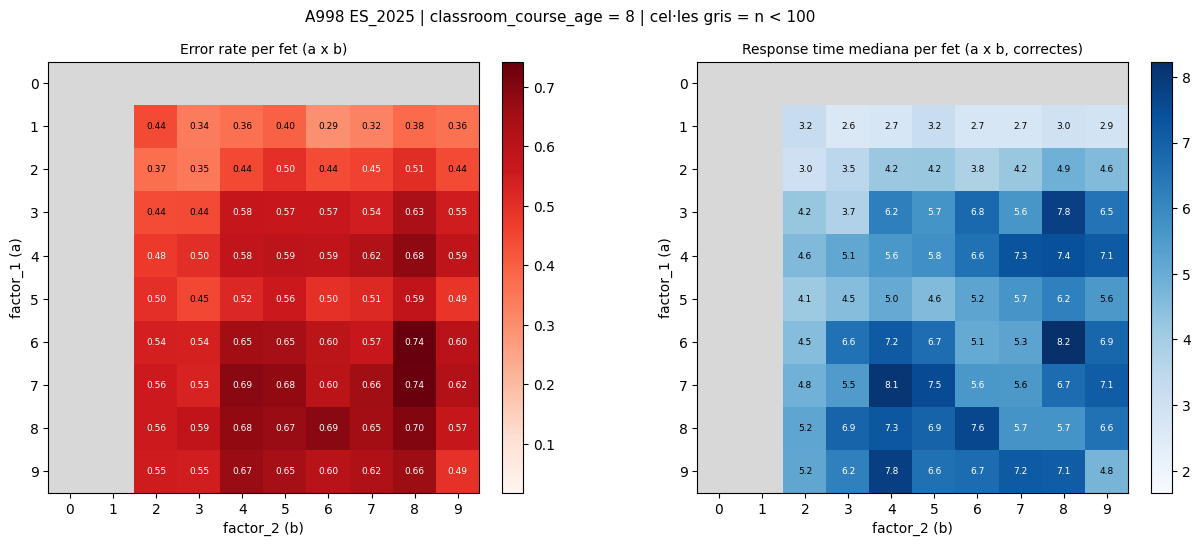

Plot -> descriptive\plots\a998_fact_heatmap_age08.png


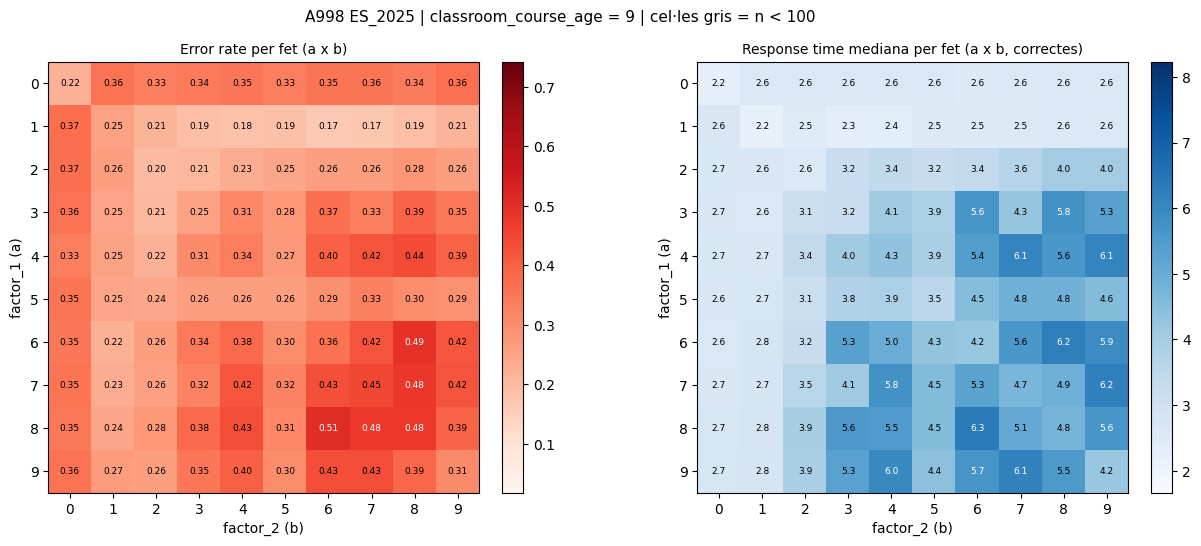

Plot -> descriptive\plots\a998_fact_heatmap_age09.png


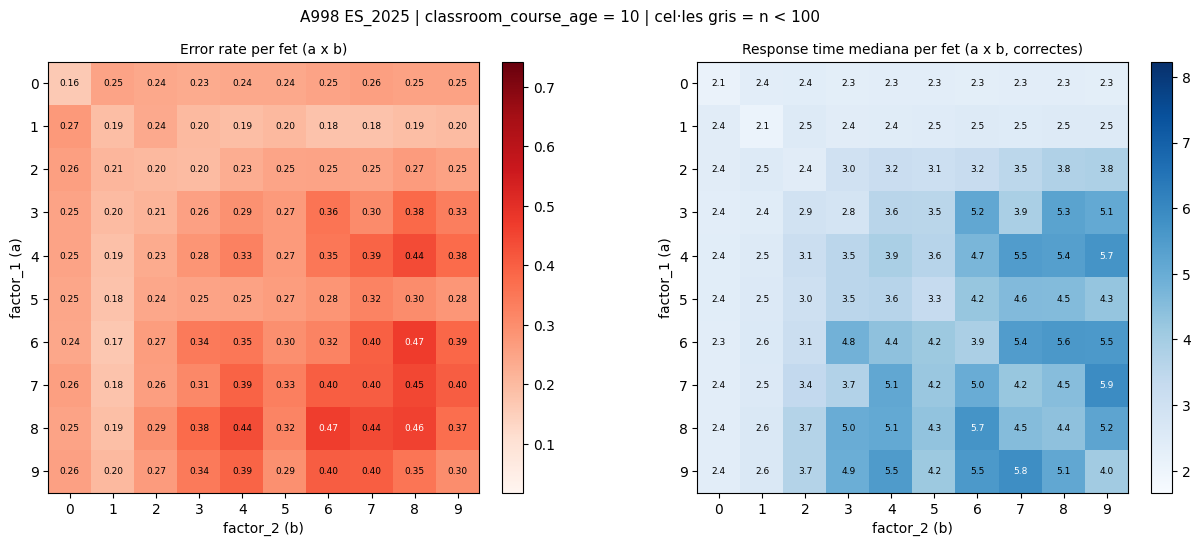

Plot -> descriptive\plots\a998_fact_heatmap_age10.png


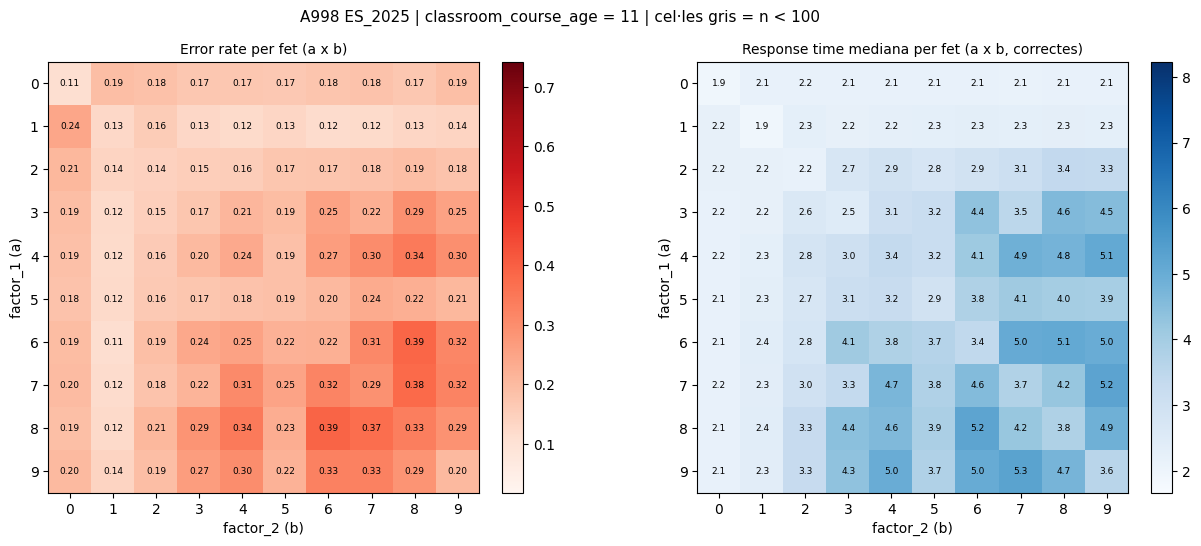

Plot -> descriptive\plots\a998_fact_heatmap_age11.png


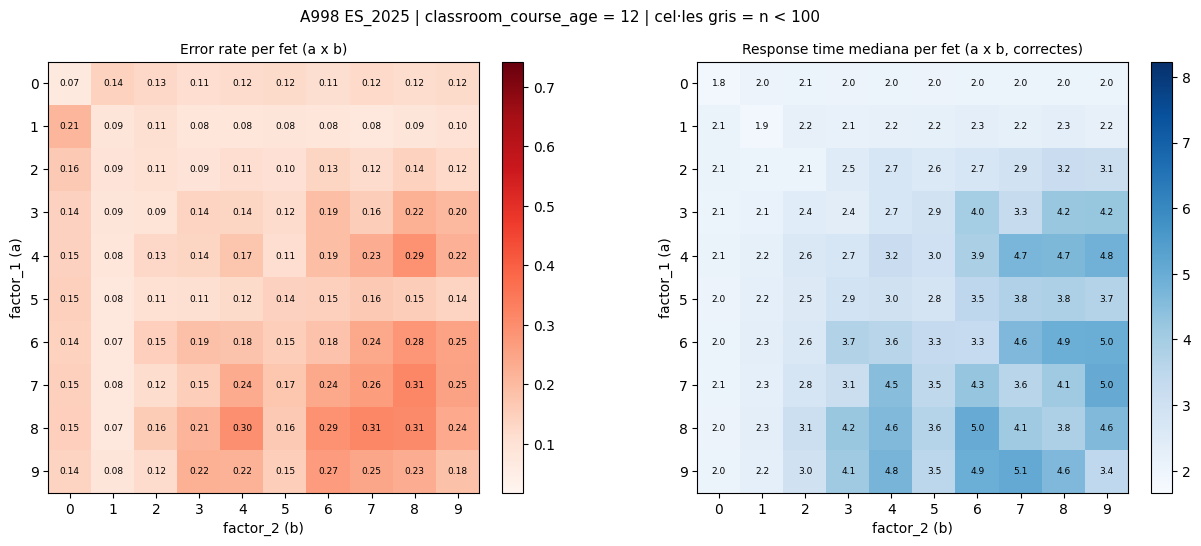

Plot -> descriptive\plots\a998_fact_heatmap_age12.png


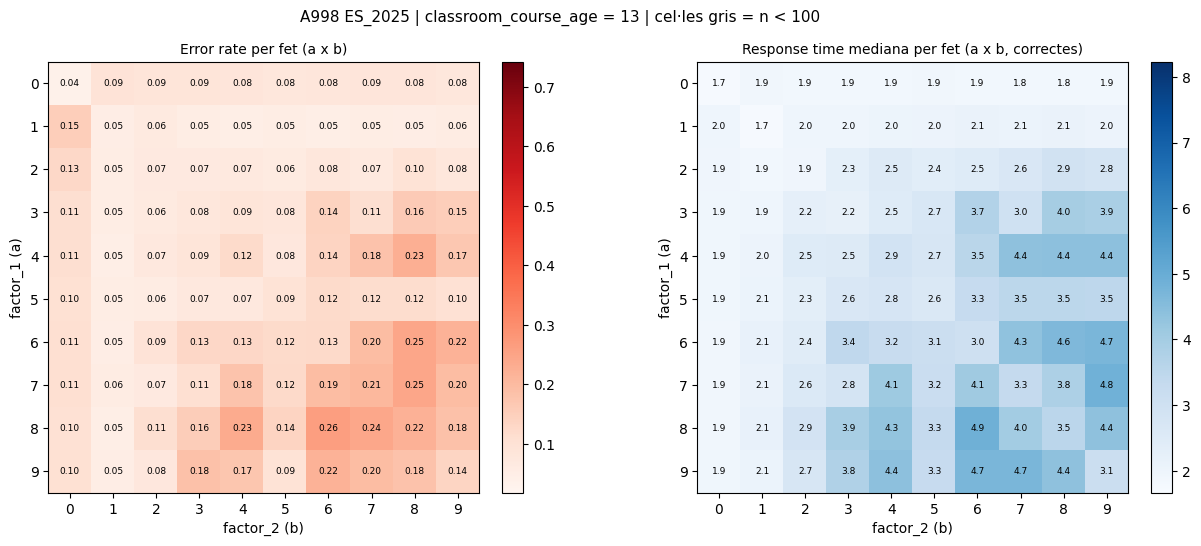

Plot -> descriptive\plots\a998_fact_heatmap_age13.png


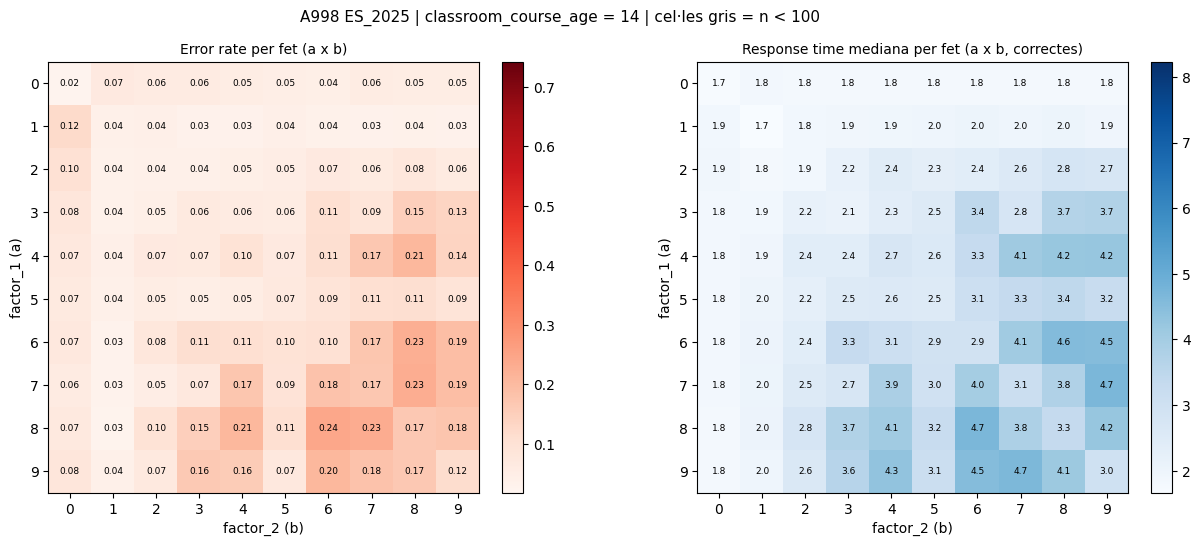

Plot -> descriptive\plots\a998_fact_heatmap_age14.png


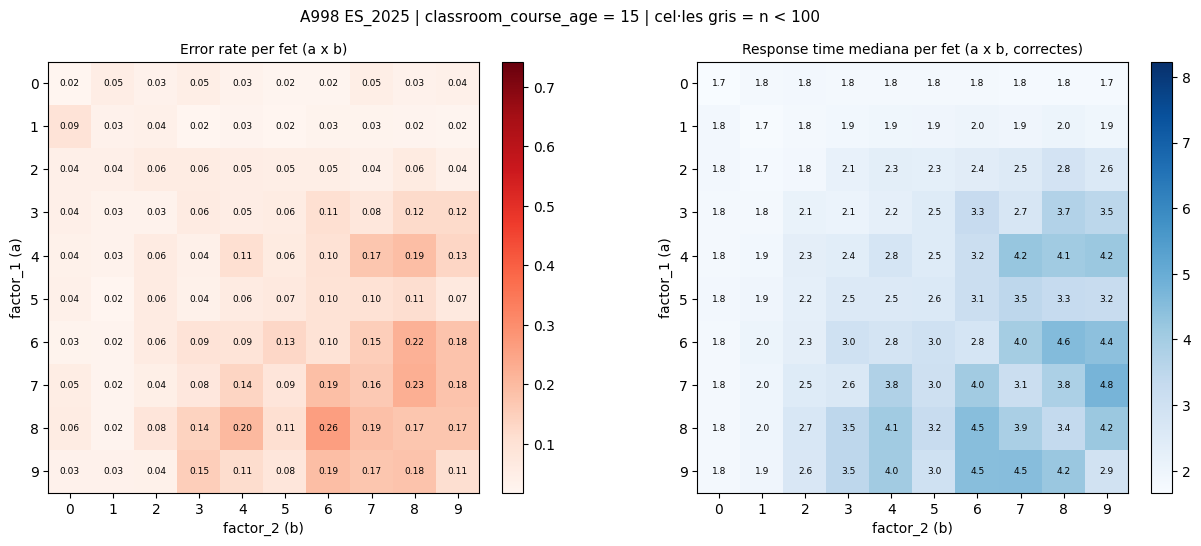

Plot -> descriptive\plots\a998_fact_heatmap_age15.png


In [24]:
# --- un heatmap per cada edat (8-15) ---------------------------------------
for age in range(8, 16):
    plot_fact_heatmaps(age)

In [25]:
# --- ranking per edat: quines operacions concretes son les mes dificils ----
# Mateixes dades que els heatmaps (caselles amb n >= FACT_MIN_N nomes), pero
# en forma de llista ordenada en lloc de matriu -- per llegir directament
# "les 10 operacions mes dificils a edat X" sense haver de buscar-les al mapa
# de colors. Dues llistes per edat (no combinades en un sol score): la mes
# errada i la mes lenta poden no coincidir (com ja vam veure a nivell de
# taula amb 9 vs 7/6).
TOP_N = 10

valid_fact = fact_df[fact_df["n"] >= FACT_MIN_N].copy()
valid_fact["operation"] = valid_fact["factor_1"].astype(str) + "×" + valid_fact["factor_2"].astype(str)

for age in range(8, 16):
    d = valid_fact[valid_fact["classroom_course_age"] == age]
    print(f"\n=========== edat {age} ===========")

    print(f"Top {TOP_N} per ERROR RATE:")
    print(d.sort_values("error_rate", ascending=False)
           [["operation", "error_rate", "n"]]
           .head(TOP_N)
           .to_string(index=False))

    print(f"\nTop {TOP_N} per RESPONSE TIME (mediana, correctes):")
    print(d.sort_values("median_rt", ascending=False)
           [["operation", "median_rt", "n_correct"]]
           .head(TOP_N)
           .to_string(index=False))


=========== edat 8 ===========
Top 10 per ERROR RATE:
operation  error_rate     n
      6×8      0.7419 16816
      7×8      0.7354 17023
      8×8      0.7023 17060
      8×6      0.6902  5138
      7×4      0.6888 17090
      4×8      0.6805 17018
      7×5      0.6792 41484
      8×4      0.6774 17064
      9×4      0.6677 17058
      8×5      0.6665 41400

Top 10 per RESPONSE TIME (mediana, correctes):
operation  median_rt  n_correct
      6×8     8.2330       4341
      7×4     8.0650       5319
      9×4     7.8340       5668
      3×8     7.8150       6279
      8×6     7.6215       1592
      7×5     7.5340      13307
      4×8     7.4330       5437
      4×7     7.3335       2018
      8×4     7.2510       5505
      6×4     7.1660       5961

=========== edat 9 ===========
Top 10 per ERROR RATE:
operation  error_rate     n
      8×6      0.5050 14736
      6×8      0.4947 15023
      7×8      0.4812 15226
      8×8      0.4780 15306
      8×7      0.4764 15051
      7×7     